# dataset of theme

In [ ]:
from datasets import load_dataset

ds = load_dataset("alwalid54321/Arabic_Poems")

print(ds["train"].column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

poems.csv:   0%|          | 0.00/27.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8875 [00:00<?, ? examples/s]

['Unnamed: 0', 'poem_title', 'poem_meter', 'poem_verses', 'poem_theme', 'poet_name', 'poet_description', 'poet_era']


In [ ]:
from datasets import load_dataset
import pandas as pd
from collections import Counter

# =========================
# 1. LOAD DATASET
# =========================
ds = load_dataset("alwalid54321/Arabic_Poems")
df = ds["train"].to_pandas()

# =========================
# 2. CLEAN BASIC
# =========================
df = df.dropna(subset=["poem_theme"])
df["poem_theme"] = df["poem_theme"].astype(str).str.strip()

# =========================
# 3. COUNT ALL THEMES
# =========================
theme_counts = Counter(df["poem_theme"])

# =========================
# 4. PRINT ALL THEMES
# =========================
print("\n📌 All themes in dataset:\n")
for theme, count in theme_counts.most_common():
    print(f"{theme} → {count}")


📌 All themes in dataset:

قصيدة قصيره → 3438
قصيدة عامه → 2507
قصيدة مدح → 728
قصيدة رومنسيه → 531
قصيدة حزينه → 428
قصيدة عتاب → 270
قصيدة شوق → 200
قصيدة هجاء → 199
قصيدة غزل → 147
قصيدة رثاء → 120
قصيدة دينية → 117
قصيدة فراق → 89
قصيدة ذم → 62
قصيدة وطنيه → 32
قصيدة اعتذار → 3
قصيدة المعلقات → 2
قصيدة سياسية → 1
قصيدة الاناشيد → 1


In [ ]:
from datasets import load_dataset
import pandas as pd

# =========================
# 1. LOAD DATASET
# =========================
ds = load_dataset("alwalid54321/Arabic_Poems")
df = ds["train"].to_pandas()

# =========================
# 2. CLEAN BASIC
# =========================
df = df.dropna(subset=["poem_theme", "poem_verses"])

df["poem_theme"] = df["poem_theme"].astype(str).str.strip()
df["poem_verses"] = df["poem_verses"].astype(str).str.strip()

# =========================
# 3. MAPPING (normalize themes)
# =========================
mapping = {
    "قصيدة مدح": "مدح",
    "قصيدة غزل": "غزل",
    "قصيدة رثاء": "رثاء",
    "قصيدة هجاء": "هجاء",
    "قصيدة ذم": "هجاء",
    "قصيدة دينية": "زهد",
    "قصيدة وطنية": "حماسة",
    "قصيدة سياسية": "حماسة",
    "قصيدة حزينه": "رثاء",
    "قصيدة فراق": "غزل",
    "قصيدة شوق": "غزل",
    "قصيدة عتاب": "غزل",
}

df["poem_theme"] = df["poem_theme"].replace(mapping)

# =========================
# 4. DROP UNWANTED THEMES
# =========================
drop_list = [
    "قصيدة قصيره",
    "قصيدة عامه",
    "قصيدة اعتذار",
    "قصيدة المعلقات",
    "قصيدة الاناشيد"
]

df_clean = df[~df["poem_theme"].isin(drop_list)]

# =========================
# 5. KEEP ONLY REQUIRED COLUMNS
# =========================
df_clean = df_clean[["poem_verses", "poem_theme"]]

# =========================
# 6. SAVE FILE
# =========================
df_clean.to_csv("clean_poem_theme_final.csv", index=False)

print("✅ Done cleaning dataset!")
print("📊 Final size:", len(df_clean))
print("📌 Final themes:\n", df_clean["poem_theme"].value_counts())

✅ Done cleaning dataset!
📊 Final size: 2924
📌 Final themes:
 poem_theme
مدح              728
غزل              706
رثاء             548
قصيدة رومنسيه    531
هجاء             261
زهد              117
قصيدة وطنيه       32
حماسة              1
Name: count, dtype: int64


# DATSET OF METRE

In [ ]:
import pandas as pd
import re

# =========================
# 1. LOAD DATASET
# =========================
df = pd.read_csv("Arabic_Poetry_Dataset.csv", encoding="latin1")

# =========================
# 2. KEEP ONLY COLUMNS
# =========================
df = df[["poem_text", "poem_tags"]].dropna()

# =========================
# 3. FIX ENCODING
# =========================
def fix(x):
    try:
        return x.encode("latin1").decode("utf-8")
    except:
        return x

df["poem_text"] = df["poem_text"].astype(str).apply(fix)
df["poem_tags"] = df["poem_tags"].astype(str).apply(fix)

# =========================
# 4. EXTRACT METER
# =========================
def get_meter(text):
    m = re.search(r"بحر\s+[^\s,]+", text)
    return m.group(0) if m else None

df["poem_meter"] = df["poem_tags"].apply(get_meter)
df = df.dropna(subset=["poem_meter"])

# =========================
# 5. SPLIT POEM INTO VERSES
# =========================
df["poem_text"] = df["poem_text"].str.replace("\n", "|")

df = df.assign(
    poem_text=df["poem_text"].str.split("|")
).explode("poem_text")

# =========================
# 6. CLEAN VERSES
# =========================
df["poem_text"] = df["poem_text"].str.strip()
df = df[df["poem_text"] != ""]

# =========================
# 7. FINAL DATASET (ONLY COLUMNS YOU WANT)
# =========================
df_final = df[["poem_text", "poem_meter"]]

# =========================
# 8. SAVE CLEAN FILE
# =========================
df_final.to_csv(
    "final_poetry_per_verse.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
import pandas as pd

# قراءة الملف
df = pd.read_csv("clean_arabic_poetry_16_meters.csv", encoding="utf-8")

# تقسيم النص على أول فاصلة
split_cols = df['poem_text'].str.split(',', n=1, expand=True)

# العمود الأول: النص
df['text'] = split_cols[0]

# العمود الثاني: البحر لي جا بعد الفاصلة (إذا كاين)
if split_cols.shape[1] > 1:
    df['meter_from_text'] = split_cols[1]
else:
    df['meter_from_text'] = ""

# نخلو الأعمدة لي نحتاجوهم
df_final = df[['text', 'meter_from_text', 'poem_meter']]

# حفظ الملف مع encoding صحيح
df_final.to_csv("final_clean.csv", sep=';', index=False, encoding='utf-8-sig')

Exception ignored in: <function ZipFile.__del__ at 0x7fef556d7ec0>
Traceback (most recent call last):
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1966, in __del__
    self.close()
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1983, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


In [ ]:
import pandas as pd

# قراءة الملف
df = pd.read_csv("final_clean.csv", sep=';', encoding='utf-8-sig')

# عرض البحور الموجودة (unique)
print("📌 البحور المختلفة:")
print(df['poem_meter'].unique())

# عدد كل بحر
print("\n📊 عدد كل بحر:")
print(df['poem_meter'].value_counts())

📌 البحور المختلفة:
['بحر الوافر' 'بحر البسيط' 'بحر الرجز' 'بحر الطويل' 'بحر المتقارب'
 'بحر الكامل' 'بحر المنسرح' 'بحر السريع' 'بحر الرمل' 'بحر الخفيف'
 'بحر مجزوء الكامل' 'بحر مجزوء الطويل' 'بحر المجتث' 'بحر أحذ الكامل'
 'بحر المديد' 'بحر الهزج' 'بحر مجزوء البسيط' 'بحر مشطور الرجز'
 'بحر مجزوء الرمل' 'بحر مجزوء الرجز' 'بحر مجزوء الوافر' 'بحر مخلع البسيط'
 'بحر مجزوء الخفيف' 'بحر مجزوء المديد' 'بحر منهوك المنسرح' 'بحر الدوبيت'
 'بحر مجزوء المتقارب' 'بحر المواليا' 'بحر مخلع موشح' 'بحر المتدارك'
 'بحر المضارع' 'بحر مخلع الكامل' 'بحر مجزوء السريع' 'بحر المقتضب'
 'بحر موشح' 'بحر مجزوء المنسرح' 'بحر مجزوء الهزج' 'بحر مجزوء الدوبيت'
 'بحر منهوك الرجز' 'بحر القوما' 'بحر مجزوء موشح' 'بحر مجزوء المواليا'
 'بحر منهوك الكامل' 'بحر تفعيلة الكامل' 'بحر السلسلة' 'بحر مجزوء المجتث'
 'بحر منهوك البسيط' 'بحر مخلع الرمل' 'بحر مجزوء المتدارك'
 'بحر مخلع السريع' 'بحر أحذ الوافر' 'بحر مخلع الرجز' 'بحر مشطور الطويل'
 'بحر مربع الرجز' 'بحر مشطور السريع']

📊 عدد كل بحر:
poem_meter
بحر الطويل            18880


In [ ]:
import pandas as pd

# قراءة الملف
df = pd.read_csv("final_clean.csv", sep=';', encoding='utf-8-sig')

# قائمة البحور الكلاسيكية
classic_bhoor = [
    'بحر الطويل', 'بحر المديد', 'بحر البسيط', 'بحر الوافر',
    'بحر الكامل', 'بحر الهزج', 'بحر الرجز', 'بحر الرمل',
    'بحر السريع', 'بحر المنسرح', 'بحر الخفيف', 'بحر المضارع',
    'بحر المقتضب', 'بحر المجتث', 'بحر المتقارب', 'بحر المتدارك'
]

# فلترة الداتا
df_clean = df[df['poem_meter'].isin(classic_bhoor)]

# نشوف النتيجة
print(df_clean['poem_meter'].value_counts())

# نحفظ ملف جديد
df_clean.to_csv("classic_16_bhoor.csv", sep=';', index=False, encoding='utf-8-sig')

poem_meter
بحر الطويل      18880
بحر الكامل       9736
بحر البسيط       9415
بحر الوافر       6395
بحر الخفيف       5254
بحر السريع       4382
بحر المتقارب     3297
بحر المنسرح      2140
بحر الرجز        1910
بحر الرمل        1354
بحر المجتث        938
بحر الهزج         440
بحر المديد        390
بحر المتدارك       42
بحر المضارع        12
بحر المقتضب        12
Name: count, dtype: int64


In [ ]:
import pandas as pd

# قراءة ملف البحور الكلاسيكية
df = pd.read_csv("classic_16_bhoor.csv", sep=';', encoding='utf-8-sig')

# حذف العمود
df = df.drop(columns=['meter_from_text'])

# حفظ النتيجة
df.to_csv("classic_16_clean.csv", sep=';', index=False, encoding='utf-8-sig')

In [ ]:
import pandas as pd

df = pd.read_csv("classic_16_clean.csv")

# تشوف أول 5 سطور
print(df.head())

# تشوف عدد السطور والـ columns
print(df.shape)

# أسماء الأعمدة
print(df.columns)

# معلومات عامة على الداتا
print(df.info())

# إحصائيات
print(df.describe())

                                     text;poem_meter
0  سَلامٌ في الصَحيفَةِ مِن لَقيطٍ\nإِلى مَن بِال...
1  يا دارَ عَمرَةَ مِن مُحتَلِّها الجَرَعا\nهاجَت...
2  وَخانَنا خَوّانٌ في اِرتِباعِنا\nفَاِنفَدَّ لِ...
3  تَنَحَّ إِلَيكُم يا اِبنَ كوزٍ فَإِنَّنا\nوَإِ...
4  تُطارِحُهُ الأَنسابُ حَتّى رَدَدنَهُ\nإِلى نَس...
(64597, 1)
Index(['text;poem_meter'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64597 entries, 0 to 64596
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   text;poem_meter  64597 non-null  object
dtypes: object(1)
memory usage: 504.8+ KB
None
                                          text;poem_meter
count                                               64597
unique                                              64258
top     كان الوداد منغِّصا لوُشاتنا\nولو ارتموا ما بين...
freq                                                    3


In [ ]:
import pandas as pd

df = pd.read_csv("classic_16_clean.csv")

# split column into 2
df = df['text;poem_meter'].str.split(';', expand=True)

df.columns = ['text', 'poem_meter']

df = df.dropna()

print(df.head())

# =========================
# SAVE NEW FILE
# =========================
df.to_csv("clean_data.csv", index=False, encoding="utf-8")

                                                text  poem_meter
0  سَلامٌ في الصَحيفَةِ مِن لَقيطٍ\nإِلى مَن بِال...  بحر الوافر
1  يا دارَ عَمرَةَ مِن مُحتَلِّها الجَرَعا\nهاجَت...  بحر البسيط
2  وَخانَنا خَوّانٌ في اِرتِباعِنا\nفَاِنفَدَّ لِ...   بحر الرجز
3  تَنَحَّ إِلَيكُم يا اِبنَ كوزٍ فَإِنَّنا\nوَإِ...  بحر الطويل
4  تُطارِحُهُ الأَنسابُ حَتّى رَدَدنَهُ\nإِلى نَس...  بحر الطويل


In [ ]:
import pandas as pd

# =========================
# 1. READ WRONG FILE (1 column)
# =========================
df = pd.read_csv("classic_16_clean.csv")

print("Before fix shape:", df.shape)
print(df.head())

# =========================
# 2. SPLIT THE SINGLE COLUMN
# =========================
df = df.iloc[:, 0].str.split(';', expand=True)

# =========================
# 3. RENAME COLUMNS
# =========================
df.columns = ['text', 'poem_meter']

# =========================
# 4. CLEAN DATA
# =========================
df = df.dropna()

# =========================
# 5. CHECK RESULT
# =========================
print("\nAfter fix shape:", df.shape)
print(df.head())

# =========================
# 6. SAVE FIXED FILE
# =========================
df.to_csv("classic_16_fixed.csv", index=False, encoding="utf-8")

Before fix shape: (64597, 1)
                                     text;poem_meter
0  سَلامٌ في الصَحيفَةِ مِن لَقيطٍ\nإِلى مَن بِال...
1  يا دارَ عَمرَةَ مِن مُحتَلِّها الجَرَعا\nهاجَت...
2  وَخانَنا خَوّانٌ في اِرتِباعِنا\nفَاِنفَدَّ لِ...
3  تَنَحَّ إِلَيكُم يا اِبنَ كوزٍ فَإِنَّنا\nوَإِ...
4  تُطارِحُهُ الأَنسابُ حَتّى رَدَدنَهُ\nإِلى نَس...

After fix shape: (64597, 2)
                                                text  poem_meter
0  سَلامٌ في الصَحيفَةِ مِن لَقيطٍ\nإِلى مَن بِال...  بحر الوافر
1  يا دارَ عَمرَةَ مِن مُحتَلِّها الجَرَعا\nهاجَت...  بحر البسيط
2  وَخانَنا خَوّانٌ في اِرتِباعِنا\nفَاِنفَدَّ لِ...   بحر الرجز
3  تَنَحَّ إِلَيكُم يا اِبنَ كوزٍ فَإِنَّنا\nوَإِ...  بحر الطويل
4  تُطارِحُهُ الأَنسابُ حَتّى رَدَدنَهُ\nإِلى نَس...  بحر الطويل


In [ ]:
import pandas as pd

file_path = "classic_16_fixed.csv"

# =========================
# 1. TRY MULTIPLE ENCODINGS
# =========================
encodings = ["utf-8", "utf-8-sig", "latin1"]

df = None

for enc in encodings:
    try:
        df = pd.read_csv(file_path, encoding=enc)
        print(f"Loaded successfully with encoding: {enc}")
        break
    except Exception as e:
        print(f"Failed with {enc}: {e}")

# =========================
# 2. IF STILL NOT WORKING → TRY SEP FIX
# =========================
if df is None:
    try:
        df = pd.read_csv(file_path, encoding="utf-8", sep=";")
        print("Loaded with sep=';'")
    except Exception as e:
        print("Still failed:", e)

# =========================
# 3. FINAL CLEAN CHECK
# =========================
if df is not None:
    print("\nSHAPE:", df.shape)
    print(df.head())
    print(df.info())

    # remove nulls + duplicates
    df = df.dropna()
    df = df.drop_duplicates()

    print("\nAFTER CLEANING:", df.shape)

else:
    print("❌ File could not be loaded. Check file format.")

Loaded successfully with encoding: utf-8

SHAPE: (64597, 2)
                                                text  poem_meter
0  سَلامٌ في الصَحيفَةِ مِن لَقيطٍ\nإِلى مَن بِال...  بحر الوافر
1  يا دارَ عَمرَةَ مِن مُحتَلِّها الجَرَعا\nهاجَت...  بحر البسيط
2  وَخانَنا خَوّانٌ في اِرتِباعِنا\nفَاِنفَدَّ لِ...   بحر الرجز
3  تَنَحَّ إِلَيكُم يا اِبنَ كوزٍ فَإِنَّنا\nوَإِ...  بحر الطويل
4  تُطارِحُهُ الأَنسابُ حَتّى رَدَدنَهُ\nإِلى نَس...  بحر الطويل
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64597 entries, 0 to 64596
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        64597 non-null  object
 1   poem_meter  64597 non-null  object
dtypes: object(2)
memory usage: 1009.5+ KB
None

AFTER CLEANING: (64258, 2)


In [ ]:
import pandas as pd

file_path = "classic_16_fixed.csv"

# =========================
# 1. READ WITH STRONG ENCODING TRY
# =========================
encodings = ["utf-8", "utf-8-sig", "cp1256", "latin1"]

df = None

for enc in encodings:
    try:
        df = pd.read_csv(file_path, encoding=enc)
        print(f"Loaded with: {enc}")
        break
    except:
        pass

if df is None:
    raise Exception("❌ File cannot be read")

# =========================
# 2. CLEAN TEXT (REMOVE GARBAGE)
# =========================
import re

def clean_arabic(text):
    text = str(text)

    # remove encoding garbage
    text = text.encode("utf-8", errors="ignore").decode("utf-8")

    # keep Arabic only
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)

    # clean spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df['text'] = df['text'].apply(clean_arabic)

# =========================
# 3. CLEAN DATA
# =========================
df = df.dropna()
df = df.drop_duplicates()

# =========================
# 4. SAVE CLEAN FILE (IMPORTANT)
# =========================
df.to_csv(
    "classic_16_clean_final.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ DONE - Clean file saved")
print(df.head())

Loaded with: utf-8
✅ DONE - Clean file saved
                                                text  poem_meter
0  سَلامٌ في الصَحيفَةِ مِن لَقيطٍ إِلى مَن بِالج...  بحر الوافر
1  يا دارَ عَمرَةَ مِن مُحتَلِّها الجَرَعا هاجَت ...  بحر البسيط
2  وَخانَنا خَوّانٌ في اِرتِباعِنا فَاِنفَدَّ لِل...   بحر الرجز
3  تَنَحَّ إِلَيكُم يا اِبنَ كوزٍ فَإِنَّنا وَإِن...  بحر الطويل
4  تُطارِحُهُ الأَنسابُ حَتّى رَدَدنَهُ إِلى نَسَ...  بحر الطويل


In [ ]:
import pandas as pd

df = pd.read_csv("classic_16_clean_final.csv")

# =========================
# 1. BASIC INFO
# =========================
print("SHAPE:", df.shape)
print("\nCOLUMNS:", df.columns)

# =========================
# 2. MISSING VALUES
# =========================
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

# =========================
# 3. EMPTY COLUMNS CHECK
# =========================
print("\n===== EMPTY COLUMNS =====")

empty_cols = []

for col in df.columns:
    if df[col].isnull().all() or df[col].astype(str).str.strip().eq("").all():
        empty_cols.append(col)

if len(empty_cols) == 0:
    print("❌ No empty columns - all columns have data")
else:
    print("⚠️ Empty columns:", empty_cols)

# =========================
# 4. SAMPLE DATA
# =========================
print("\n===== SAMPLE =====")
print(df.head())

# =========================
# 5. COLUMN TYPE CHECK
# =========================
print("\n===== DATA TYPES =====")
print(df.dtypes)

# =========================
# 6. UNIQUE VALUES PER COLUMN
# =========================
print("\n===== UNIQUE VALUES =====")
for col in df.columns:
    print(col, ":", df[col].nunique())

SHAPE: (64255, 2)

COLUMNS: Index(['text', 'poem_meter'], dtype='object')

===== MISSING VALUES =====
text          1
poem_meter    0
dtype: int64

===== EMPTY COLUMNS =====
❌ No empty columns - all columns have data

===== SAMPLE =====
                                                text  poem_meter
0  سَلامٌ في الصَحيفَةِ مِن لَقيطٍ إِلى مَن بِالج...  بحر الوافر
1  يا دارَ عَمرَةَ مِن مُحتَلِّها الجَرَعا هاجَت ...  بحر البسيط
2  وَخانَنا خَوّانٌ في اِرتِباعِنا فَاِنفَدَّ لِل...   بحر الرجز
3  تَنَحَّ إِلَيكُم يا اِبنَ كوزٍ فَإِنَّنا وَإِن...  بحر الطويل
4  تُطارِحُهُ الأَنسابُ حَتّى رَدَدنَهُ إِلى نَسَ...  بحر الطويل

===== DATA TYPES =====
text          object
poem_meter    object
dtype: object

===== UNIQUE VALUES =====
text : 64240
poem_meter : 16


#EDA EBDAY MEN HENA


Shape: (18773, 2)


,text,poem_meter
0,سَلامٌ في الصَحيفَةِ مِن لَقيطٍ إِلى مَن بِالج...,بحر الوافر
1,يا دارَ عَمرَةَ مِن مُحتَلِّها الجَرَعا هاجَت ...,بحر البسيط
2,وَخانَنا خَوّانٌ في اِرتِباعِنا فَاِنفَدَّ لِل...,بحر الرجز
3,تَنَحَّ إِلَيكُم يا اِبنَ كوزٍ فَإِنَّنا وَإِن...,بحر الطويل
4,تُطارِحُهُ الأَنسابُ حَتّى رَدَدنَهُ إِلى نَسَ...,بحر الطويل



===== INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18773 entries, 0 to 18772
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        18773 non-null  object
 1   poem_meter  18772 non-null  object
dtypes: object(2)
memory usage: 293.5+ KB
None

===== MISSING VALUES =====
text          0
poem_meter    1
dtype: int64

===== DUPLICATES =====
Duplicates: 2

===== TEXT LENGTH STATS =====
count    18773.000000
mean        99.371065
std        164.098033
min          3.000000
25%         20.000000
50%         43.000000
75%        109.000000
max       7986.000000
Name: text_len, dtype: float64


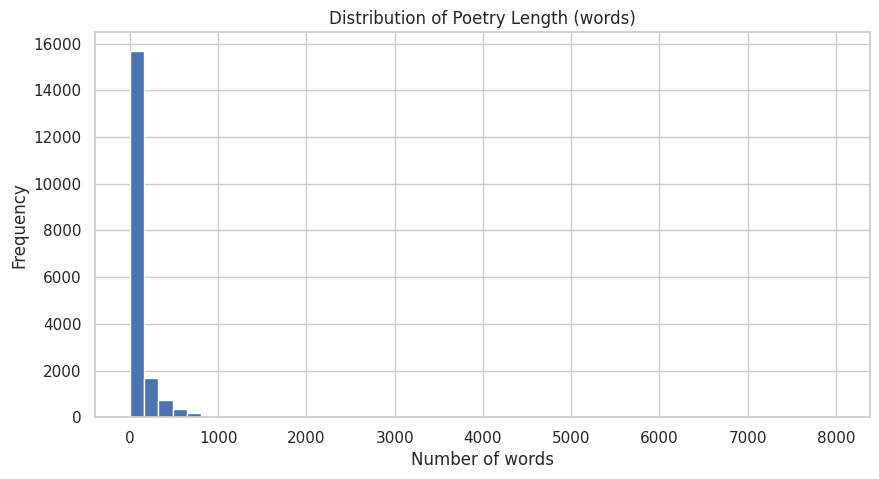

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


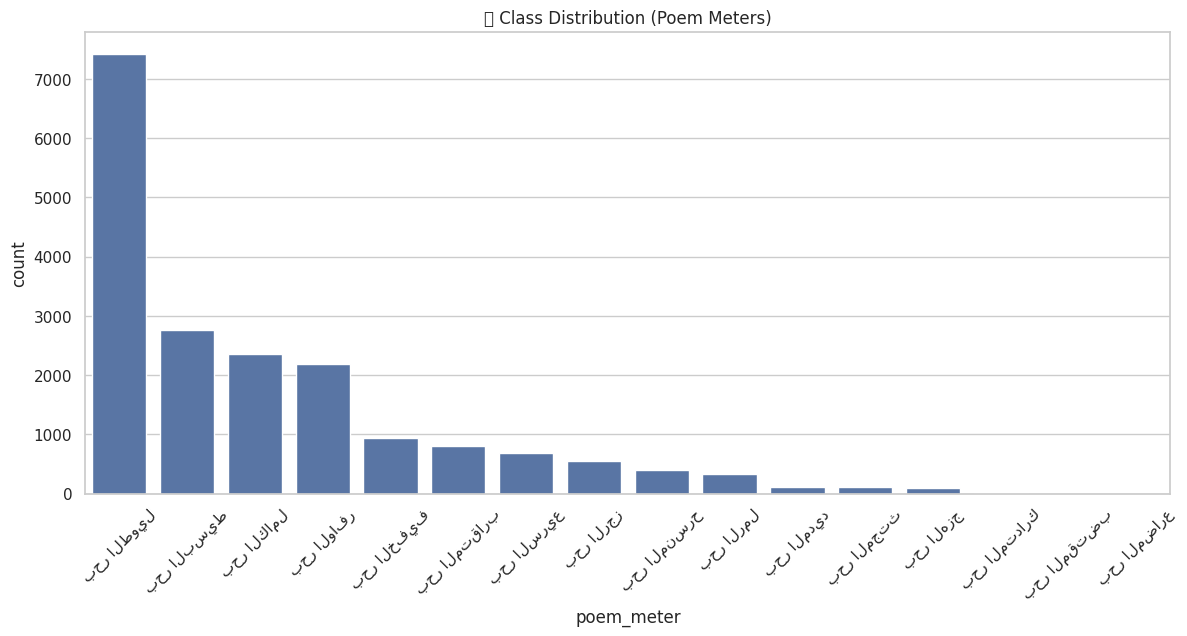


===== CLASS COUNTS =====
poem_meter
بحر الطويل      7426
بحر البسيط      2756
بحر الكامل      2355
بحر الوافر      2189
بحر الخفيف       941
بحر المتقارب     813
بحر السريع       692
بحر الرجز        557
بحر المنسرح      393
بحر الرمل        329
بحر المديد       108
بحر المجتث       107
بحر الهزج         91
بحر المتدارك      12
بحر المقتضب        2
بحر المضارع        1
Name: count, dtype: int64


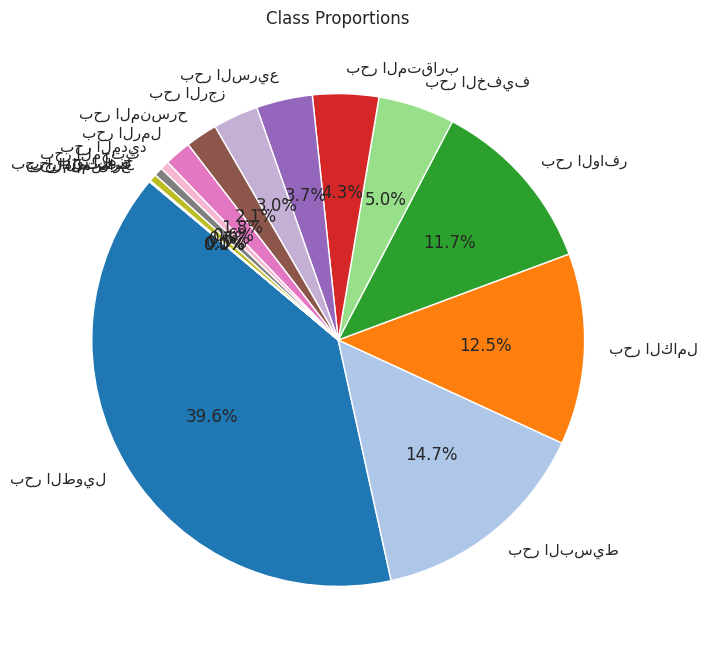

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


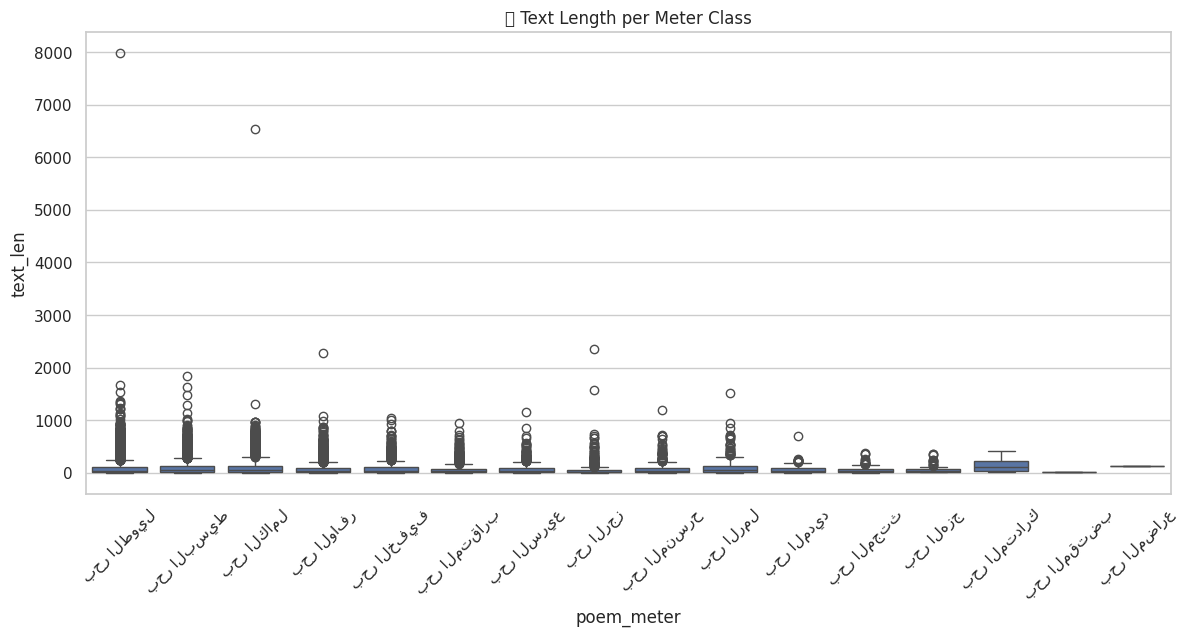


===== LONGEST POEMS =====


,text,poem_meter,text_len
14344,سَقَتني حُمَيَّا الحُبَّ راحَةَ مُقلَتي وَكَأس...,بحر الطويل,7986
18496,كتبَ العذارُ على الخدودِ سُطورا من يَتْلُها يَ...,بحر الكامل,6531
13474,وَمَغرَبِ الشَمسِ وَمِشرِقِ القَمَر وَكَوكَبِ ...,بحر الرجز,2350



===== SHORTEST POEMS =====


,text,poem_meter,text_len
4264,تَقولُها ناكِحَةً أُوَيسا,بحر الرجز,3
10362,لِاِبنِ شَنَقناقٍ وَشَيصَبانِ,بحر الرجز,3
3505,وَخَناذيذَ خِصيَةً وَفُحولا,بحر الخفيف,3


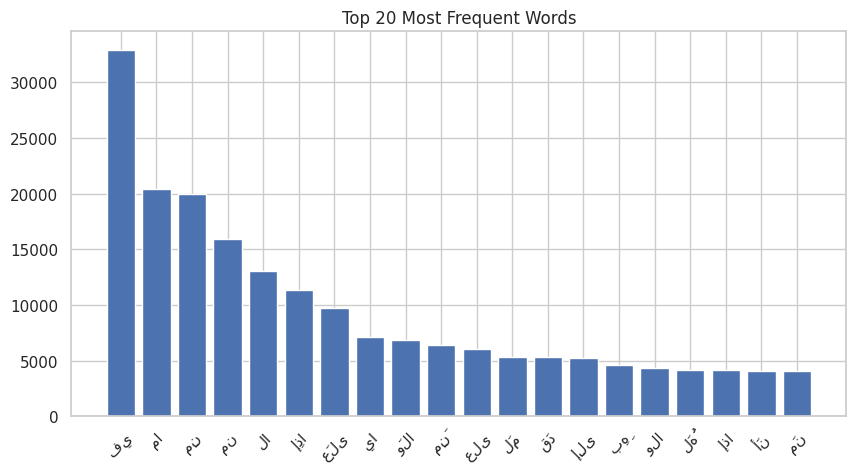

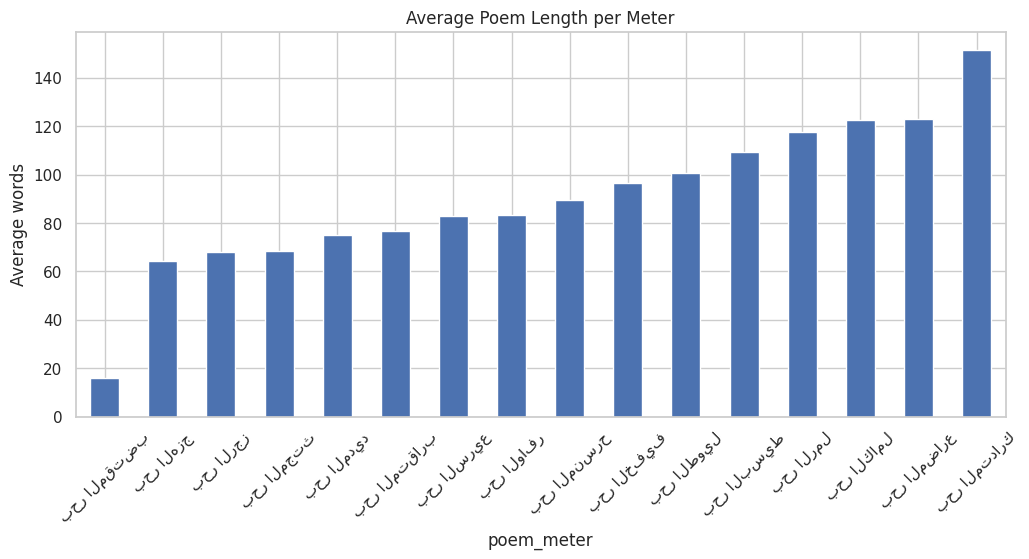

✅ EDA Completed Successfully


In [ ]:
# =========================
# 📊 EDA + VISUALIZATION (ARABIC POETRY METER DATASET)
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

sns.set(style="whitegrid")

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("classic_16_clean_final (1).csv")

print("Shape:", df.shape)
display(df.head())

# =========================
# 2. BASIC INFO
# =========================
print("\n===== INFO =====")
print(df.info())

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== DUPLICATES =====")
print("Duplicates:", df.duplicated(subset=["text"]).sum())

# =========================
# 3. TEXT LENGTH ANALYSIS
# =========================
df["text_len"] = df["text"].astype(str).apply(lambda x: len(x.split()))

print("\n===== TEXT LENGTH STATS =====")
print(df["text_len"].describe())

plt.figure(figsize=(10,5))
plt.hist(df["text_len"], bins=50)
plt.title("Distribution of Poetry Length (words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

# =========================
# 4. LABEL DISTRIBUTION
# =========================
plt.figure(figsize=(14,6))
order = df["poem_meter"].value_counts().index

sns.countplot(data=df, x="poem_meter", order=order)
plt.xticks(rotation=45)
plt.title("📊 Class Distribution (Poem Meters)")
plt.show()

# =========================
# 5. TOP CLASSES
# =========================
print("\n===== CLASS COUNTS =====")
print(df["poem_meter"].value_counts())

# =========================
# 6. PIE CHART (BALANCE VIEW)
# =========================
plt.figure(figsize=(8,8))
df["poem_meter"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=140,
    cmap="tab20"
)
plt.title("Class Proportions")
plt.ylabel("")
plt.show()

# =========================
# 7. LENGTH PER CLASS
# =========================
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x="poem_meter", y="text_len", order=order)
plt.xticks(rotation=45)
plt.title("📏 Text Length per Meter Class")
plt.show()

# =========================
# 8. TOP LONGEST / SHORTEST EXAMPLES
# =========================
print("\n===== LONGEST POEMS =====")
display(df.sort_values("text_len", ascending=False)[["text", "poem_meter", "text_len"]].head(3))

print("\n===== SHORTEST POEMS =====")
display(df.sort_values("text_len")[["text", "poem_meter", "text_len"]].head(3))

# =========================
# 9. WORD FREQUENCY (GLOBAL)
# =========================
from collections import Counter

all_words = " ".join(df["text"].astype(str)).split()
counter = Counter(all_words)

common_words = counter.most_common(20)

words, counts = zip(*common_words)

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.show()

# =========================
# 10. CLASS VS LENGTH MEAN
# =========================
mean_len = df.groupby("poem_meter")["text_len"].mean().sort_values()

plt.figure(figsize=(12,5))
mean_len.plot(kind="bar")
plt.title("Average Poem Length per Meter")
plt.ylabel("Average words")
plt.xticks(rotation=45)
plt.show()

# =========================
# DONE
# =========================
print("✅ EDA Completed Successfully")